<h1 align="center">
    Practical 3: Data Cleaning and Visualization
</h1>

# Data Cleaning and Visualization in Python

**Why this matters**
- Real-world data is messy: missing values, wrong types, duplicates, outliers.
- Cleaning is 70-80% of a data analyst's work.
- Visualization helps explore patterns, detect issues, and communicate insights.

**Goals**
1. Load and explore a real dataset.
2. Clean common data problems systematically.
3. Create insightful visualizations.


### 1. Import the necessary libraries

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#To suppress all warnings
import warnings
warnings.filterwarnings('ignore')

### 2. Loading and Exploration

In [115]:
# Load Titanic dataset
df = sns.load_dataset('titanic')

# have a quick look
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [116]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [117]:
# Statistical summary (numeric only)
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [118]:
# Categorical summary
df.describe(include=['object', 'category'])

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [119]:
# Check for missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [120]:
# check duplicates
df.duplicated().sum()

np.int64(107)

## Data Cleaning

**Common issues in Titanic:**
- Missing values: age (177), embarked (2), deck (688), embtown (not useful)
- Data types: some could be categorical
- Outliers
- Redundant/unuseful columns

### Handling Missing Values

In [121]:
# 1. Drop columns with too many missing values (>70%)
df_clean = df.drop(columns=['deck'])

In [122]:
# 2. Fill 'age' with median (robust to outliers)
median_age = df_clean['age'].median()
df_clean['age'] = df_clean['age'].fillna(median_age)

In [123]:
# 3. Fill 'embarked' with mode (most frequent)
mode_embarked = df_clean['embarked'].mode()[0]
df_clean['embarked'] = df_clean['embarked'].fillna(mode_embarked)

In [124]:
# 4. Fill 'embark_town' with mode 
# df_clean = df_clean.drop(columns=['embark_town'])

In [125]:
df_clean.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

### Data Types and Categories

In [126]:
# Convert to categorical for memory and plotting
categorical_cols = ['sex', 'embarked', 'class', 'who', 'adult_male', 'alone']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

In [127]:
# Verify
df_clean.dtypes

survived          int64
pclass            int64
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who            category
adult_male     category
embark_town         str
alive               str
alone          category
dtype: object

### Duplicates and Redundant Columns

In [128]:
# Remove exact duplicates (none in this dataset, but good practice)
df_clean.drop_duplicates(inplace=True)

In [129]:
df_clean.shape

(775, 14)

In [130]:
# Drop redundant columns
df_clean = df_clean.drop(columns=['alive', 'pclass', 'embark_town'])

### Outlier Detection

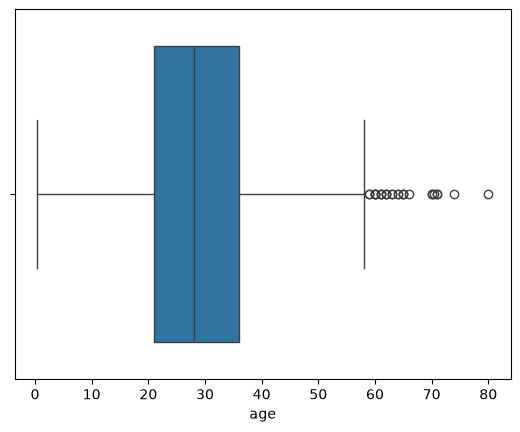

In [131]:
# Boxplot for fare and age
sns.boxplot(x=df_clean['age']);

<Axes: xlabel='fare'>

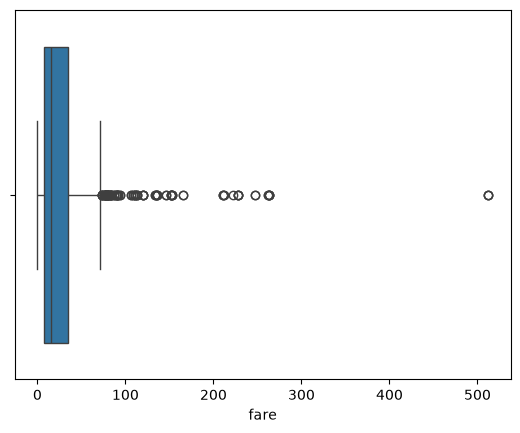

In [132]:
sns.boxplot(x=df_clean['fare'])

In [133]:
# Optional: Cap extreme fares using IQR method
# Q3 + 1.5 * IQR > high outlier
# Q1 - 1.5 * IQR < low outlier
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1

UPPER_BOUND = Q3 + 1.5 * IQR
df_clean['fare'] = df_clean['fare'].clip(upper=UPPER_BOUND)


<Axes: xlabel='fare'>

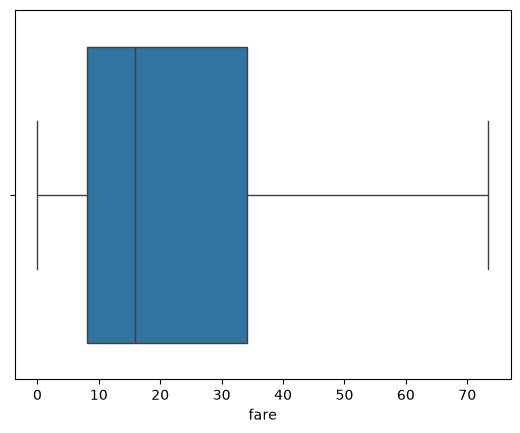

In [134]:
sns.boxplot(x=df_clean['fare'])

## Visualizations

**We will create:**
- Distribution plots
- Categorical counts
- Relationships (scatter, box)
- Correlation heatmap

### Univariate Plots

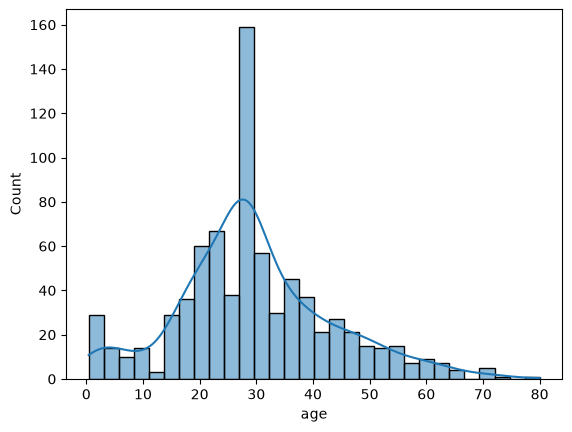

In [146]:
sns.histplot(df_clean['age'], kde=True, bins=30);

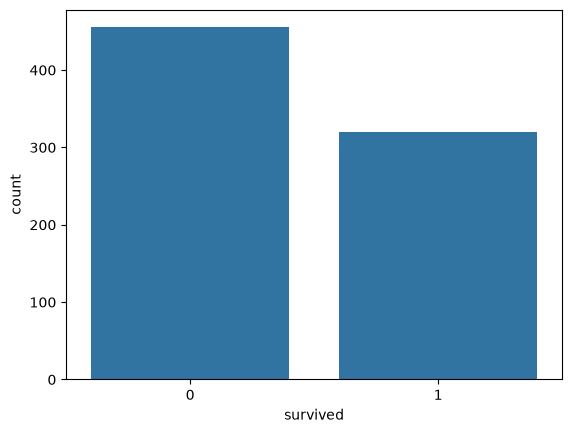

In [150]:
sns.countplot(x='survived', data=df_clean);

### Categorical Relationships

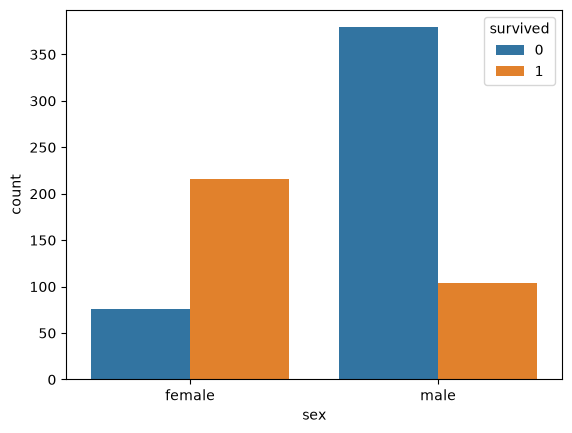

In [160]:
sns.countplot(x='sex', hue='survived', data=df_clean);

# Survival by sex

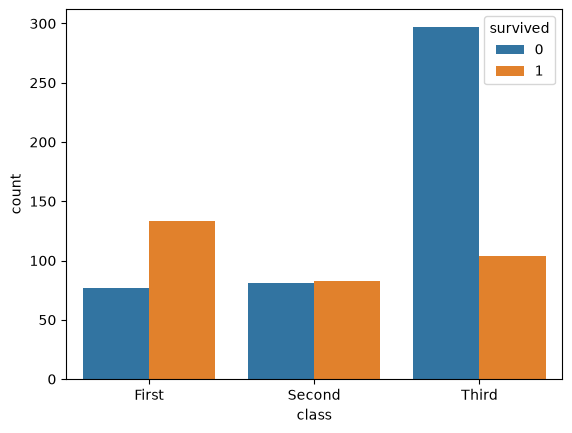

In [158]:
sns.countplot(x='class', hue='survived', data=df_clean);


# Survival by class

### Numerical Relationships

In [136]:
# Age vs Fare, colored by survival


In [137]:
# Boxplot: Age by Class


### Pairplot and Heatmap

In [138]:
# Pairplot for key variables


In [139]:
# Correlation heatmap
